In [1]:
import os
import sys
import numpy as np
import pandas as pd
import nibabel as nib
import nilearn
from nilearn.image import resample_img
from nilearn import plotting
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from nilearn import masking
# from natsort import natsorted
import pickle

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, train_test_split
import matplotlib.pyplot as plt
from scipy.stats import zscore

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import KFold
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Load MNI mask for ROIs betas

In [3]:
maskDir = 'N:\Experimental_Data\yujunchen\projects\data\masks'
maskFile = os.path.join(maskDir, 'MNI152_T1_2mm_brain_mask.nii.gz')
mask = nib.load(maskFile)
mask.get_fdata().shape

(91, 109, 91)

## Resample MNI mask


In [4]:
temp_nii_path = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\GLM_singletrial\\betas\Sub1\\beta_0001.nii'
temp_nii_data = nib.load(temp_nii_path)
temp_nii_data.get_fdata().shape

(79, 95, 79)

In [5]:
resampled_mask = resample_img(mask, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
resampled_mask.shape

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_43372\943945802.py:1: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled_mask = resample_img(mask, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_43372\943945802.py:1: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled_mask = resample_img(mask, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)


(79, 95, 79)

# Load beta

In [6]:
dataDir = '../GLM_singletrial/betas/'
subs = ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub8', 'Sub9', 'Sub11', 'Sub12', 'Sub13', 'Sub14', 'Sub15', 'Sub16', 'Sub17', 'Sub18', 'Sub19', 'Sub20',
        'Sub21', 'Sub22', 'Sub23', 'Sub24', 'Sub25', 'Sub26', 'Sub27', 'Sub28', 'Sub29', 'Sub30', 'Sub31']

# Loop through each subject and assert their existence
for sub in subs:
    sub_path = os.path.join(dataDir, sub)
    if not os.path.isdir(sub_path):
        raise FileNotFoundError(f"Folder for {sub} does not exist at path: {sub_path}")
    else:
        print(f"Folder for {sub} exists at path: {sub_path}")

Folder for Sub1 exists at path: ../GLM_singletrial/betas/Sub1
Folder for Sub2 exists at path: ../GLM_singletrial/betas/Sub2
Folder for Sub3 exists at path: ../GLM_singletrial/betas/Sub3
Folder for Sub4 exists at path: ../GLM_singletrial/betas/Sub4
Folder for Sub5 exists at path: ../GLM_singletrial/betas/Sub5
Folder for Sub6 exists at path: ../GLM_singletrial/betas/Sub6
Folder for Sub7 exists at path: ../GLM_singletrial/betas/Sub7
Folder for Sub8 exists at path: ../GLM_singletrial/betas/Sub8
Folder for Sub9 exists at path: ../GLM_singletrial/betas/Sub9
Folder for Sub11 exists at path: ../GLM_singletrial/betas/Sub11
Folder for Sub12 exists at path: ../GLM_singletrial/betas/Sub12
Folder for Sub13 exists at path: ../GLM_singletrial/betas/Sub13
Folder for Sub14 exists at path: ../GLM_singletrial/betas/Sub14
Folder for Sub15 exists at path: ../GLM_singletrial/betas/Sub15
Folder for Sub16 exists at path: ../GLM_singletrial/betas/Sub16
Folder for Sub17 exists at path: ../GLM_singletrial/betas/

In [7]:
len(subs)

30

In [ ]:
# ============================================================
# PART 1 — LOAD BETAS AND CREATE df
# ============================================================
import os
import re
import numpy as np
import nibabel as nib
import pandas as pd

dataDir = '../GLM_singletrial/betas/'

subs = ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub8', 'Sub9',
        'Sub11', 'Sub12', 'Sub13', 'Sub14', 'Sub15', 'Sub16', 'Sub17', 'Sub18',
        'Sub19', 'Sub20', 'Sub21', 'Sub22', 'Sub23', 'Sub24', 'Sub25', 'Sub26',
        'Sub27', 'Sub28', 'Sub29', 'Sub30', 'Sub31']


def get_beta_files(sub_path):
    files = [
        f for f in os.listdir(sub_path)
        if re.match(r"beta_\d+.*\.(nii|nii\.gz|img)$", f)
    ]

    files = sorted(
        files,
        key=lambda x: int(re.search(r"beta_(\d+)", x).group(1))
    )

    return [os.path.join(sub_path, f) for f in files]


def max_beta(beta_file):
    img = nib.load(beta_file)
    data = img.get_fdata()
    return float(np.nanmax(data))


rows = []

for sub in subs:
    sub_path = os.path.join(dataDir, sub)

    if not os.path.isdir(sub_path):
        raise FileNotFoundError(f"Folder for {sub} does not exist: {sub_path}")

    beta_files = get_beta_files(sub_path)

    print(sub, "number of beta files:", len(beta_files))

    expected_min = 670
    if len(beta_files) < expected_min:
        raise ValueError(
            f"{sub} has only {len(beta_files)} beta files, expected at least {expected_min}"
        )

    # 10 runs
    for run in range(1, 11):
        run_start = (run - 1) * 66

        # Trial/stim betas: first 60 betas in each run
        stim_indices = list(range(run_start, run_start + 60))
        stim_max = max(max_beta(beta_files[idx]) for idx in stim_indices)

        rows.append({
            "subject": sub,
            "category": f"Run{run}_StimMax",
            "value": stim_max
        })

        # Motion betas: next 6 betas in each run
        for motion in range(1, 7):
            idx = run_start + 60 + (motion - 1)

            rows.append({
                "subject": sub,
                "category": f"Run{run}_Motion{motion}",
                "value": max_beta(beta_files[idx])
            })

    # Final 10 baseline betas
    for b, idx in enumerate(range(660, 670), start=1):
        rows.append({
            "subject": sub,
            "category": f"Baseline{b}",
            "value": max_beta(beta_files[idx])
        })


df = pd.DataFrame(rows)

# print(df.head())
# print(df.shape)

# df.to_csv("beta_max_values_by_subject.csv", index=False)
# print("Saved: beta_max_values_by_subject.csv")

## Plot the single trial betas

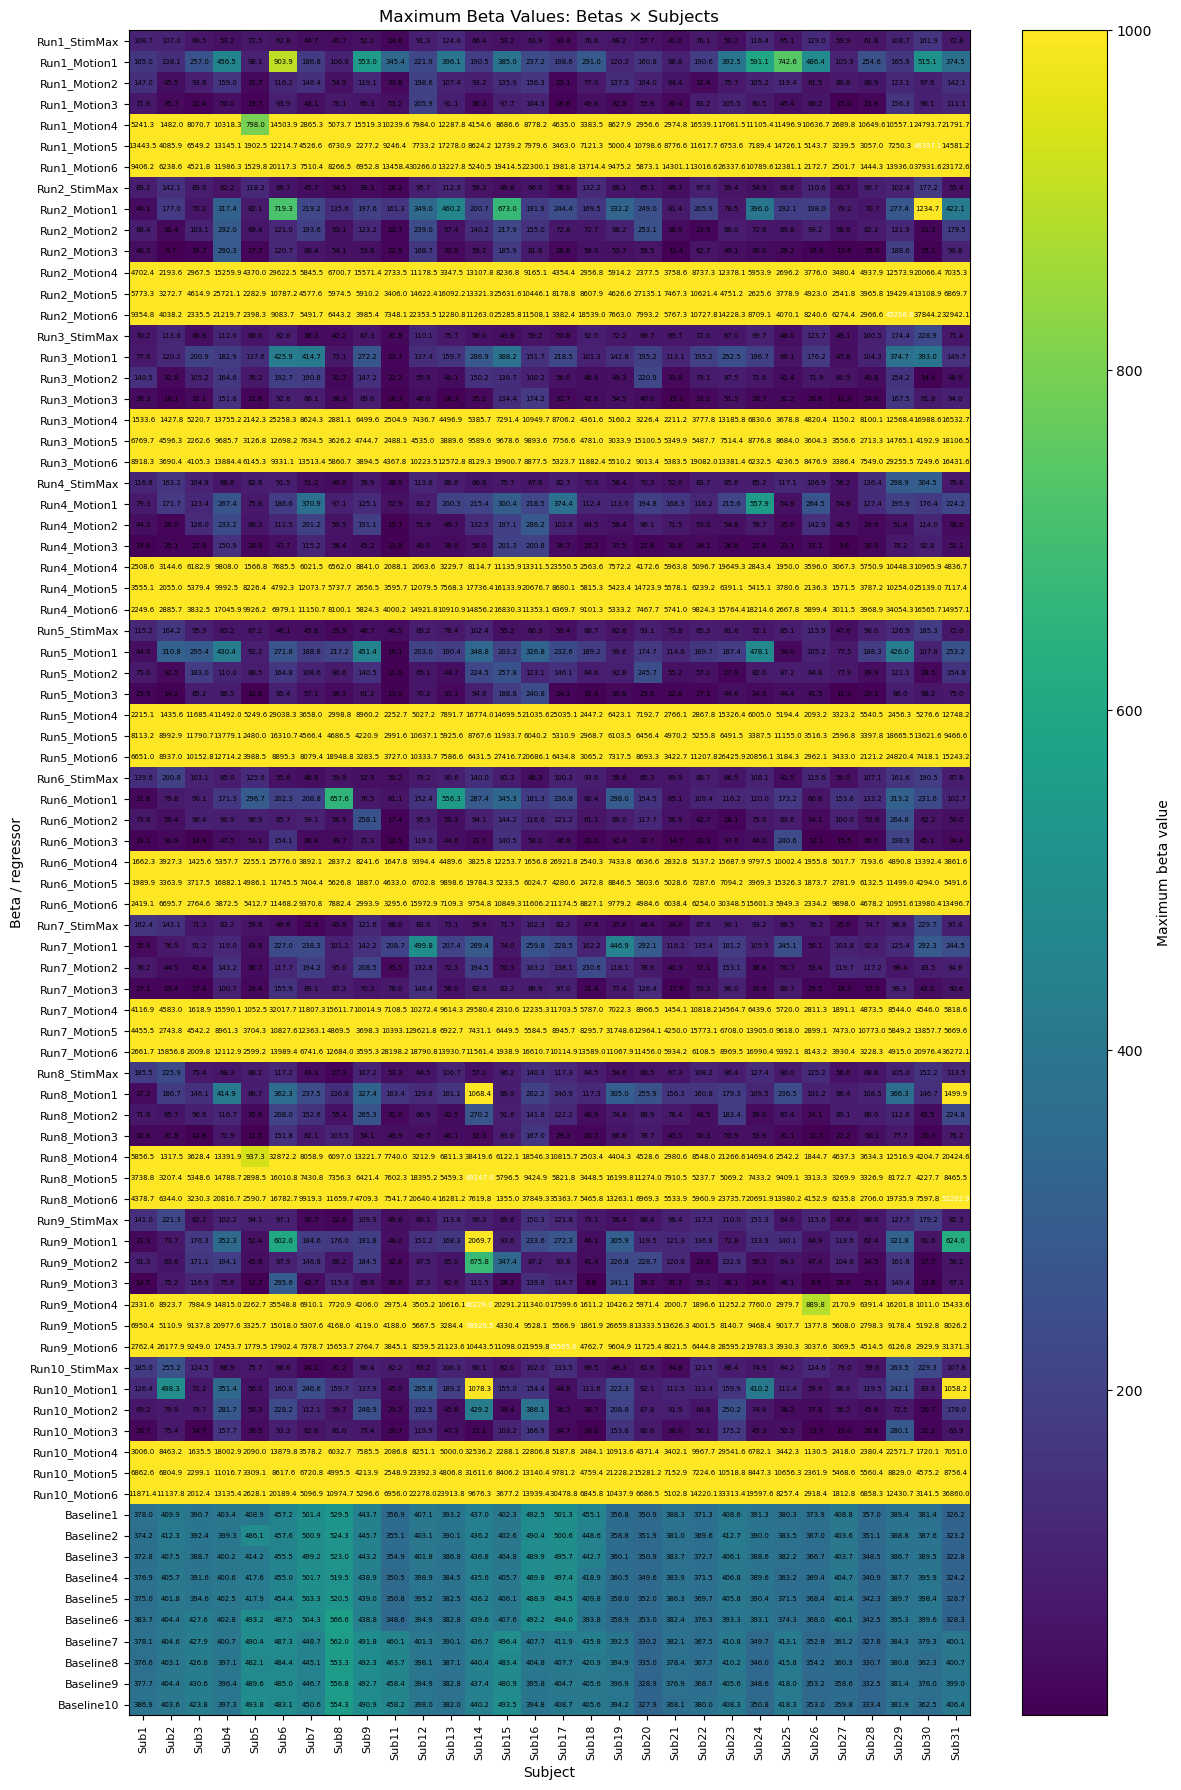

In [17]:
# ============================================================
# PART 2 — TRANSPOSED HEATMAP PLOTTING
# rows    = betas / regressors
# columns = subjects
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# If needed:
# df = pd.read_csv("beta_max_values_by_subject.csv")

# ============================================================
# ORDERING
# ============================================================

category_order = df["category"].drop_duplicates().tolist()

# ============================================================
# TRANSPOSE HEATMAP
# ============================================================

heatmap_df = df.pivot(
    index="category",
    columns="subject",
    values="value"
)

# Keep order
heatmap_df = heatmap_df.loc[category_order]
heatmap_df = heatmap_df[subs]

values = heatmap_df.values

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(12, 18))

im = plt.imshow(
    values,
    aspect="auto",
    vmin=np.nanmin(values),
    vmax=1000   # controls contrast
)

plt.colorbar(im, label="Maximum beta value")

# ============================================================
# AXES
# ============================================================

plt.yticks(
    ticks=np.arange(len(heatmap_df.index)),
    labels=heatmap_df.index,
    fontsize=8
)

plt.xticks(
    ticks=np.arange(len(heatmap_df.columns)),
    labels=heatmap_df.columns,
    rotation=90,
    fontsize=8
)

plt.ylabel("Beta / regressor")
plt.xlabel("Subject")
plt.title("Maximum Beta Values: Betas × Subjects")

# ============================================================
# ADD VALUES INTO CELLS
# ============================================================

vmin = np.nanmin(values)
vmax = np.nanmax(values)
threshold = (vmin + vmax) / 2

for i in range(values.shape[0]):      # rows = betas
    for j in range(values.shape[1]):  # cols = subjects

        val = values[i, j]

        if np.isnan(val):
            continue

        color = "white" if val > threshold else "black"

        plt.text(
            j,
            i,
            f"{val:.1f}",
            ha="center",
            va="center",
            color=color,
            fontsize=5
        )

plt.tight_layout()

plt.savefig(
    "beta_max_heatmap_transposed.png",
    dpi=300
)

plt.show()

In [10]:
rows = []

for sub in subs:
    sub_path = os.path.join(dataDir, sub)
    beta_files = get_beta_files(sub_path)

    for run in range(1, 11):
        run_start = (run - 1) * 66

        # =========================
        # Stimulus betas (1–60)
        # =========================
        stim_indices = list(range(run_start, run_start + 60))

        stim_vals = []
        for idx in stim_indices:
            val = max_beta(beta_files[idx])
            stim_vals.append((val, beta_files[idx]))

        stim_max_val, stim_max_file = max(stim_vals, key=lambda x: x[0])

        print(f"{sub} | Run {run} | Stim MAX = {stim_max_val:.4f} | File: {os.path.basename(stim_max_file)}")

        rows.append({
            "subject": sub,
            "category": f"Run{run}_StimMax",
            "value": stim_max_val,
            "file": stim_max_file
        })

        # =========================
        # Motion betas (61–66)
        # =========================
        for motion in range(1, 7):
            idx = run_start + 60 + (motion - 1)

            val = max_beta(beta_files[idx])

            print(f"{sub} | Run {run} | Motion {motion} = {val:.4f} | File: {os.path.basename(beta_files[idx])}")

            rows.append({
                "subject": sub,
                "category": f"Run{run}_Motion{motion}",
                "value": val,
                "file": beta_files[idx]
            })

    # =========================
    # Baseline betas (last 10)
    # =========================
    baseline_indices = list(range(660, 670))

    for b, idx in enumerate(baseline_indices, start=1):
        val = max_beta(beta_files[idx])

        print(f"{sub} | Baseline {b} = {val:.4f} | File: {os.path.basename(beta_files[idx])}")

        rows.append({
            "subject": sub,
            "category": f"Baseline{b}",
            "value": val,
            "file": beta_files[idx]
        })

df = pd.DataFrame(rows)

Sub1 | Run 1 | Stim MAX = 108.6916 | File: beta_0033.nii
Sub1 | Run 1 | Motion 1 = 164.9758 | File: beta_0061.nii
Sub1 | Run 1 | Motion 2 = 147.0416 | File: beta_0062.nii
Sub1 | Run 1 | Motion 3 = 71.7986 | File: beta_0063.nii
Sub1 | Run 1 | Motion 4 = 5241.3223 | File: beta_0064.nii
Sub1 | Run 1 | Motion 5 = 13443.5420 | File: beta_0065.nii
Sub1 | Run 1 | Motion 6 = 9406.1777 | File: beta_0066.nii
Sub1 | Run 2 | Stim MAX = 89.2415 | File: beta_0100.nii
Sub1 | Run 2 | Motion 1 = 40.0534 | File: beta_0127.nii
Sub1 | Run 2 | Motion 2 = 88.4174 | File: beta_0128.nii
Sub1 | Run 2 | Motion 3 = 46.3075 | File: beta_0129.nii
Sub1 | Run 2 | Motion 4 = 4702.4458 | File: beta_0130.nii
Sub1 | Run 2 | Motion 5 = 5773.3135 | File: beta_0131.nii
Sub1 | Run 2 | Motion 6 = 9354.8135 | File: beta_0132.nii
Sub1 | Run 3 | Stim MAX = 70.1905 | File: beta_0162.nii
Sub1 | Run 3 | Motion 1 = 77.5810 | File: beta_0193.nii
Sub1 | Run 3 | Motion 2 = 140.5413 | File: beta_0194.nii
Sub1 | Run 3 | Motion 3 = 36.31

KeyboardInterrupt: 

# Load beta with masks

In [19]:
# ============================================================
# LOAD BETAS + APPLY MASK + CREATE df
# ============================================================

import os
import re
import numpy as np
import nibabel as nib
import pandas as pd

from nilearn.image import resample_img

# ============================================================
# SETTINGS
# ============================================================

dataDir = '../GLM_singletrial/betas/'

subs = ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub8', 'Sub9',
        'Sub11', 'Sub12', 'Sub13', 'Sub14', 'Sub15', 'Sub16', 'Sub17', 'Sub18',
        'Sub19', 'Sub20', 'Sub21', 'Sub22', 'Sub23', 'Sub24', 'Sub25', 'Sub26',
        'Sub27', 'Sub28', 'Sub29', 'Sub30', 'Sub31']


# ============================================================
# HELPERS
# ============================================================

def get_beta_files(sub_path):

    files = [
        f for f in os.listdir(sub_path)
        if re.match(r"beta_\d+.*\.(nii|nii\.gz|img)$", f)
    ]

    files = sorted(
        files,
        key=lambda x: int(re.search(r"beta_(\d+)", x).group(1))
    )

    return [os.path.join(sub_path, f) for f in files]


# ============================================================
# LOAD TEMPLATE BETA
# ============================================================

temp_beta = get_beta_files(os.path.join(dataDir, subs[0]))[0]

temp_nii = nib.load(temp_beta)

print("Template beta shape:", temp_nii.shape)


# ============================================================
# LOAD + RESAMPLE MASK
# ============================================================

mask = resampled_mask

resampled_mask = resample_img(
    mask,
    target_affine=temp_nii.affine,
    target_shape=temp_nii.shape[:3],
    interpolation='nearest'
)

mask_bool = resampled_mask.get_fdata() > 0

print("Mask shape:", mask_bool.shape)
print("Mask voxels:", np.sum(mask_bool))


# ============================================================
# MAX BETA WITH MASK
# ============================================================

def max_beta(beta_file, mask_bool=None):

    img = nib.load(beta_file)

    data = img.get_fdata()

    if mask_bool is not None:

        if data.shape != mask_bool.shape:
            raise ValueError(
                f"Shape mismatch: beta {data.shape}, mask {mask_bool.shape}"
            )

        data = data[mask_bool]

    return float(np.nanmax(data))


# ============================================================
# EXTRACT DATA
# ============================================================

rows = []

for sub in subs:

    sub_path = os.path.join(dataDir, sub)

    if not os.path.isdir(sub_path):
        raise FileNotFoundError(f"Folder for {sub} does not exist: {sub_path}")

    beta_files = get_beta_files(sub_path)

    print(sub, "number of beta files:", len(beta_files))

    expected_min = 670

    if len(beta_files) < expected_min:
        raise ValueError(
            f"{sub} has only {len(beta_files)} beta files, expected at least {expected_min}"
        )

    # ========================================================
    # RUNS
    # ========================================================

    for run in range(1, 11):

        run_start = (run - 1) * 66

        # ----------------------------------------------------
        # Trial/stimulus betas
        # ----------------------------------------------------

        stim_indices = list(range(run_start, run_start + 60))

        stim_max = max(
            max_beta(beta_files[idx], mask_bool)
            for idx in stim_indices
        )

        rows.append({
            "subject": sub,
            "category": f"Run{run}_StimMax",
            "value": stim_max
        })

        # ----------------------------------------------------
        # Motion betas
        # ----------------------------------------------------

        for motion in range(1, 7):

            idx = run_start + 60 + (motion - 1)

            rows.append({
                "subject": sub,
                "category": f"Run{run}_Motion{motion}",
                "value": max_beta(beta_files[idx], mask_bool)
            })

    # ========================================================
    # BASELINE BETAS
    # ========================================================

    for b, idx in enumerate(range(660, 670), start=1):

        rows.append({
            "subject": sub,
            "category": f"Baseline{b}",
            "value": max_beta(beta_files[idx], mask_bool)
        })


# ============================================================
# CREATE DATAFRAME
# ============================================================

df = pd.DataFrame(rows)

print(df.head())
print(df.shape)

df.to_csv(
    "beta_max_values_by_subject_masked.csv",
    index=False
)

print("Saved: beta_max_values_by_subject_masked.csv")

Template beta shape: (79, 95, 79)
Mask shape: (79, 95, 79)
Mask voxels: 228419
Sub1 number of beta files: 670


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_43372\1011221112.py:61: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled_mask = resample_img(
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_43372\1011221112.py:61: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled_mask = resample_img(


Sub2 number of beta files: 670
Sub3 number of beta files: 670
Sub4 number of beta files: 670
Sub5 number of beta files: 670
Sub6 number of beta files: 670
Sub7 number of beta files: 670
Sub8 number of beta files: 670
Sub9 number of beta files: 670
Sub11 number of beta files: 670
Sub12 number of beta files: 670
Sub13 number of beta files: 670
Sub14 number of beta files: 670
Sub15 number of beta files: 670
Sub16 number of beta files: 670
Sub17 number of beta files: 670
Sub18 number of beta files: 670
Sub19 number of beta files: 670
Sub20 number of beta files: 670
Sub21 number of beta files: 670
Sub22 number of beta files: 670
Sub23 number of beta files: 670
Sub24 number of beta files: 670
Sub25 number of beta files: 670
Sub26 number of beta files: 670
Sub27 number of beta files: 670
Sub28 number of beta files: 670
Sub29 number of beta files: 670
Sub30 number of beta files: 670
Sub31 number of beta files: 670
  subject      category        value
0    Sub1  Run1_StimMax    42.802704
1    S

## Plot the single trial betas

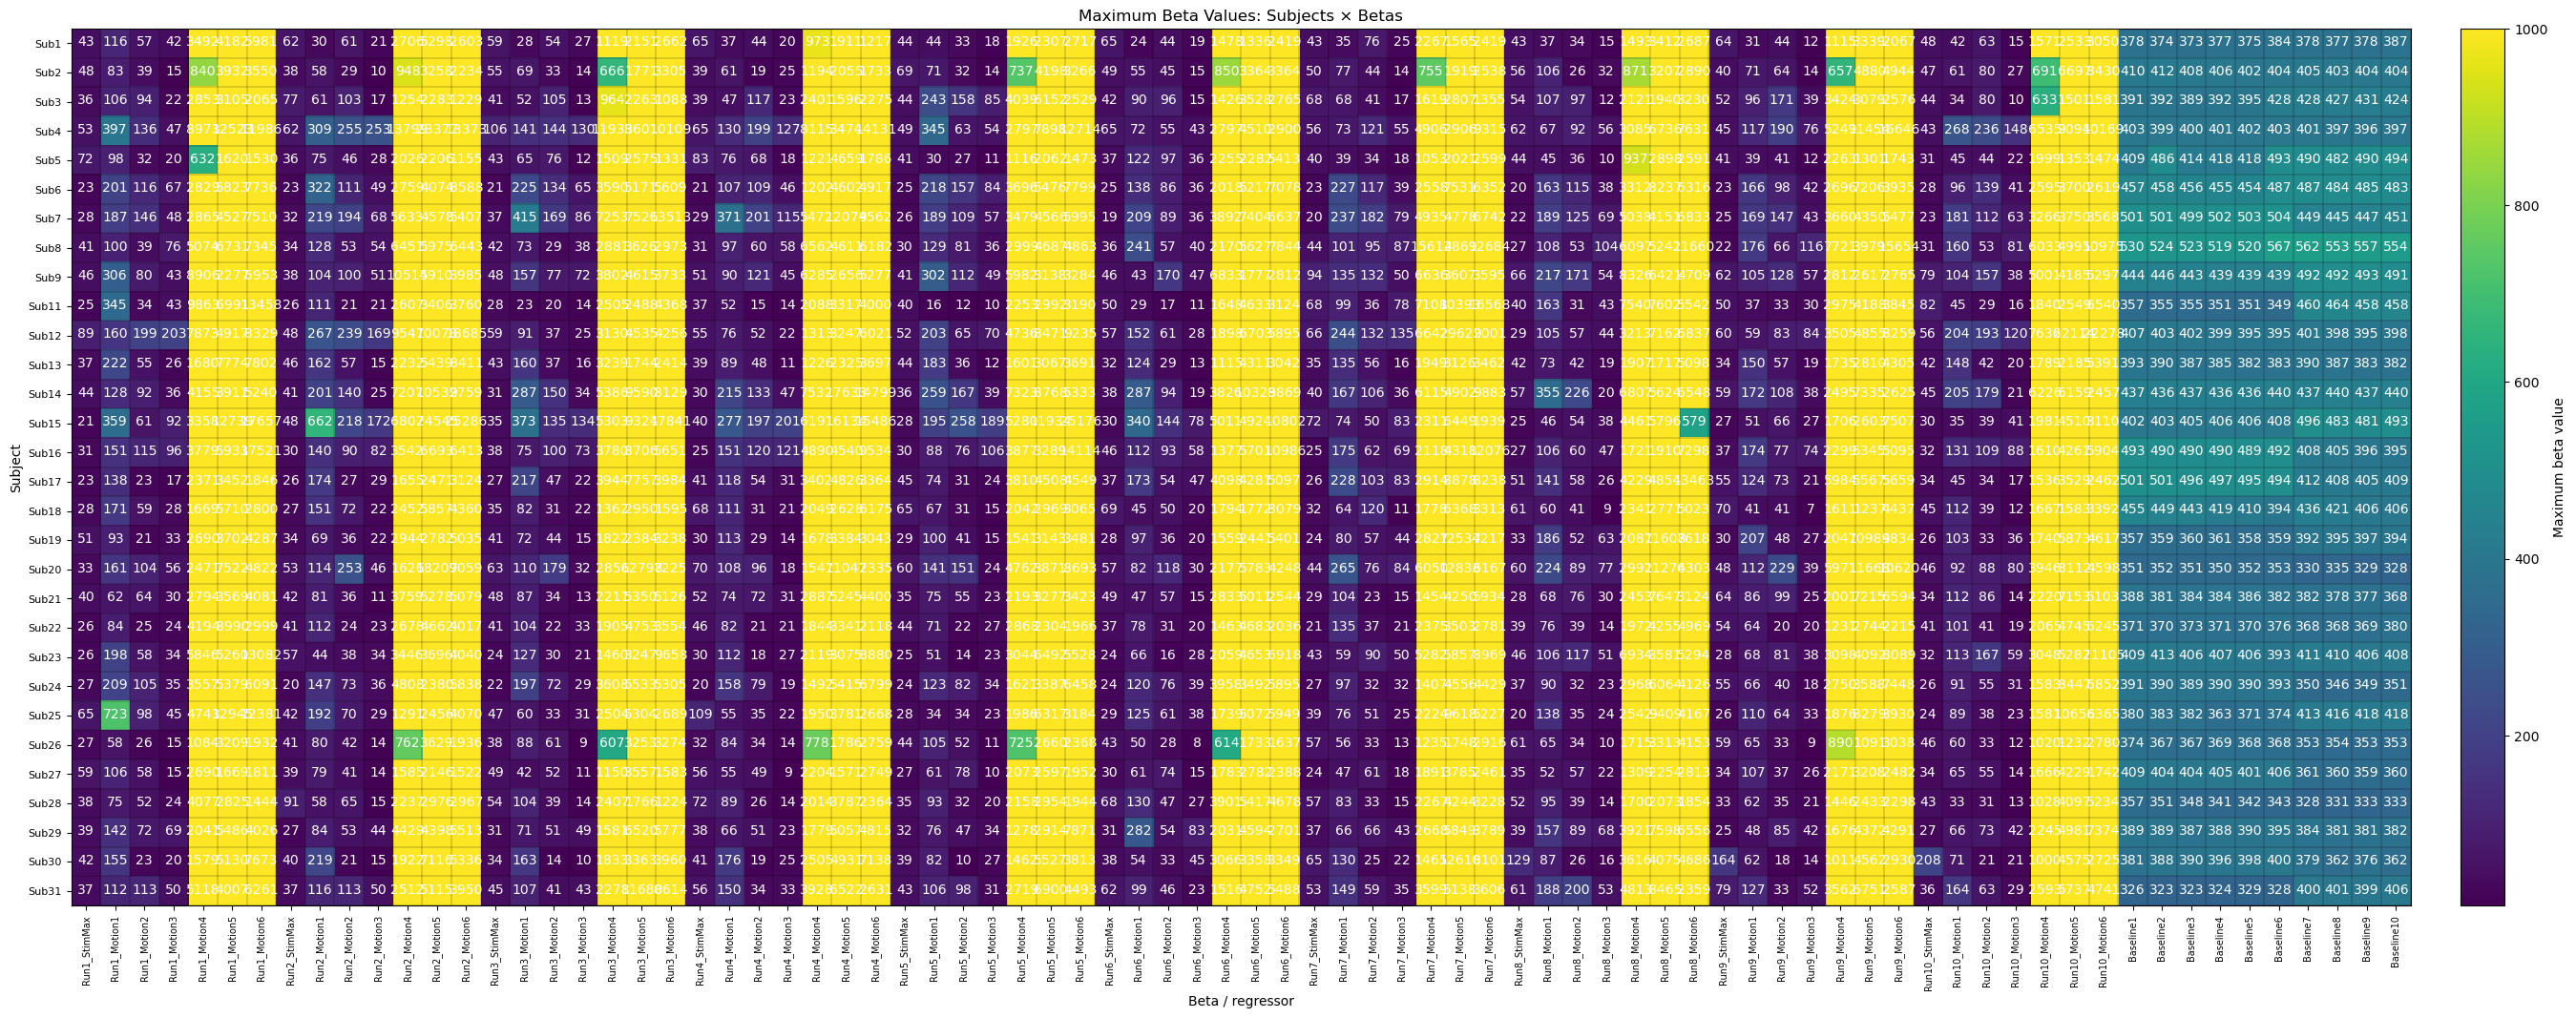

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ORDERING
# ============================================================
category_order = df["category"].drop_duplicates().tolist()

# ============================================================
# HEATMAP: rows = subjects, columns = betas/regressors
# ============================================================
heatmap_df = df.pivot(
    index="subject",
    columns="category",
    values="value"
)

heatmap_df = heatmap_df.loc[subs]
heatmap_df = heatmap_df[category_order]

values = heatmap_df.values

n_rows, n_cols = values.shape

# ============================================================
# PLOT WITH SQUARE CELLS
# ============================================================
cell_size = 0.35

fig_width = n_cols * cell_size
fig_height = n_rows * cell_size

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

vmin = np.nanmin(values)
vmax = 1000

im = ax.imshow(
    values,
    aspect="equal",
    vmin=vmin,
    vmax=vmax,
    interpolation="nearest"
)

cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label("Maximum beta value")

# ============================================================
# AXES
# ============================================================
ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels(heatmap_df.index, fontsize=8)

ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(
    heatmap_df.columns,
    rotation=90,
    fontsize=7
)

ax.set_ylabel("Subject")
ax.set_xlabel("Beta / regressor")
ax.set_title("Maximum Beta Values: Subjects × Betas")

# ============================================================
# ADD VALUES INTO CELLS
# ============================================================
for i in range(n_rows):
    for j in range(n_cols):
        val = values[i, j]

        if np.isnan(val):
            continue

        ax.text(
            j,
            i - 0.28,
            f"{int(np.round(val))}",
            ha="center",
            va="top",
            color="white",
            fontsize=10
        )

# ============================================================
# OPTIONAL CELL GRID
# ============================================================
ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
ax.grid(which="minor", color="black", linestyle="-", linewidth=0.2)
ax.tick_params(which="minor", bottom=False, left=False)

plt.tight_layout()

plt.savefig(
    "beta_max_heatmap_subjects_rows_square_cells.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()